<a href="https://www.kaggle.com/code/sonawanelalitsunil/pok-mon-stats-explorer-ml-97-05?scriptVersionId=231999640" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/1025-pokemon/all_pokemon_data.csv


### Title: Pokémon Stats Explorer

#### Description: Discover key stats of all 1025 Pokémon, including base HP, Attack, Defense, Speed, and more.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/1025-pokemon/all_pokemon_data.csv")

In [3]:
df.head()

,Name,National Dex #,Primary Typing,Secondary Typing,Secondary Typing Flag,Generation,Legendary Status,Form,Alt Form Flag,Evolution Stage,...,Weight (hg),Height (in),Weight (lbs),Base Stat Total,Health,Attack,Defense,Special Attack,Special Defense,Speed
0,bulbasaur,1,grass,poison,True,generation-i,False,Base,False,1,...,69,28,15,318,45,49,49,65,65,45
1,ivysaur,2,grass,poison,True,generation-i,False,Base,False,2,...,130,39,29,405,60,62,63,80,80,60
2,venusaur,3,grass,poison,True,generation-i,False,Base,False,3,...,1000,79,220,525,80,82,83,100,100,80
3,venusaur-mega,3,grass,poison,True,generation-i,True,Mega,True,3,...,1555,94,343,625,80,100,123,122,120,80
4,charmander,4,fire,NaN,False,generation-i,False,Base,False,1,...,85,24,19,309,39,52,43,60,50,65


In [4]:
df.tail()

,Name,National Dex #,Primary Typing,Secondary Typing,Secondary Typing Flag,Generation,Legendary Status,Form,Alt Form Flag,Evolution Stage,...,Weight (hg),Height (in),Weight (lbs),Base Stat Total,Health,Attack,Defense,Special Attack,Special Defense,Speed
1179,iron-crown,1023,steel,psychic,True,generation-ix,True,Base,False,1,...,1560,63,344,590,90,72,100,122,108,98
1180,terapagos,1024,normal,NaN,False,generation-ix,True,Base,False,1,...,65,8,14,450,90,65,85,65,85,60
1181,terapagos-terastal,1024,normal,NaN,False,generation-ix,True,Terastal,True,1,...,160,12,35,600,95,95,110,105,110,85
1182,terapagos-stellar,1024,normal,NaN,False,generation-ix,True,Stellar,True,1,...,770,67,170,700,160,105,110,130,110,85
1183,pecharunt,1025,poison,ghost,True,generation-ix,True,Base,False,1,...,3,12,1,600,88,88,160,88,88,88


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Name                   1184 non-null   object
 1   National Dex #         1184 non-null   int64 
 2   Primary Typing         1184 non-null   object
 3   Secondary Typing       654 non-null    object
 4   Secondary Typing Flag  1184 non-null   bool  
 5   Generation             1184 non-null   object
 6   Legendary Status       1184 non-null   bool  
 7   Form                   1184 non-null   object
 8   Alt Form Flag          1184 non-null   bool  
 9   Evolution Stage        1184 non-null   int64 
 10  Number of Evolution    1184 non-null   int64 
 11  Color ID               1184 non-null   object
 12  Catch Rate             1184 non-null   int64 
 13  Height (dm)            1184 non-null   int64 
 14  Weight (hg)            1184 non-null   int64 
 15  Height (in)          

In [6]:
df.describe()

,National Dex #,Evolution Stage,Number of Evolution,Catch Rate,Height (dm),Weight (hg),Height (in),Weight (lbs),Base Stat Total,Health,Attack,Defense,Special Attack,Special Defense,Speed
count,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000
mean,494.978041,1.597128,2.108108,92.202703,12.829392,730.995777,50.535473,161.163851,441.633446,70.910473,80.989020,74.817568,72.922297,72.265203,69.728885
std,299.166288,0.700700,0.735618,75.715485,13.646223,1311.060248,53.682455,289.037497,119.296702,26.406800,31.955337,30.324208,32.426324,27.095940,30.110391
min,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,4.000000,0.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,230.750000,1.000000,2.000000,45.000000,6.000000,89.750000,24.000000,20.000000,330.000000,52.000000,57.000000,52.000000,50.000000,51.000000,45.000000
50%,486.500000,1.000000,2.000000,60.000000,10.000000,300.000000,39.000000,66.000000,464.500000,70.000000,80.000000,70.000000,65.000000,70.000000,67.500000
75%,751.250000,2.000000,3.000000,127.000000,16.000000,775.500000,63.000000,171.250000,520.000000,85.000000,100.000000,91.000000,95.000000,90.000000,91.000000
max,1025.000000,3.000000,3.000000,255.000000,200.000000,9999.000000,787.000000,2204.000000,780.000000,255.000000,190.000000,230.000000,194.000000,230.000000,200.000000


In [7]:
df.isnull().sum()

Name                       0
National Dex #             0
Primary Typing             0
Secondary Typing         530
Secondary Typing Flag      0
Generation                 0
Legendary Status           0
Form                       0
Alt Form Flag              0
Evolution Stage            0
Number of Evolution        0
Color ID                   0
Catch Rate                 0
Height (dm)                0
Weight (hg)                0
Height (in)                0
Weight (lbs)               0
Base Stat Total            0
Health                     0
Attack                     0
Defense                    0
Special Attack             0
Special Defense            0
Speed                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Name                     object
National Dex #            int64
Primary Typing           object
Secondary Typing         object
Secondary Typing Flag      bool
Generation               object
Legendary Status           bool
Form                     object
Alt Form Flag              bool
Evolution Stage           int64
Number of Evolution       int64
Color ID                 object
Catch Rate                int64
Height (dm)               int64
Weight (hg)               int64
Height (in)               int64
Weight (lbs)              int64
Base Stat Total           int64
Health                    int64
Attack                    int64
Defense                   int64
Special Attack            int64
Special Defense           int64
Speed                     int64
dtype: object

In [10]:
df.shape

(1184, 24)

In [11]:
df.columns

Index(['Name', 'National Dex #', 'Primary Typing', 'Secondary Typing',
       'Secondary Typing Flag', 'Generation', 'Legendary Status', 'Form',
       'Alt Form Flag', 'Evolution Stage', 'Number of Evolution', 'Color ID',
       'Catch Rate', 'Height (dm)', 'Weight (hg)', 'Height (in)',
       'Weight (lbs)', 'Base Stat Total', 'Health', 'Attack', 'Defense',
       'Special Attack', 'Special Defense', 'Speed'],
      dtype='object')

## Data visualizations

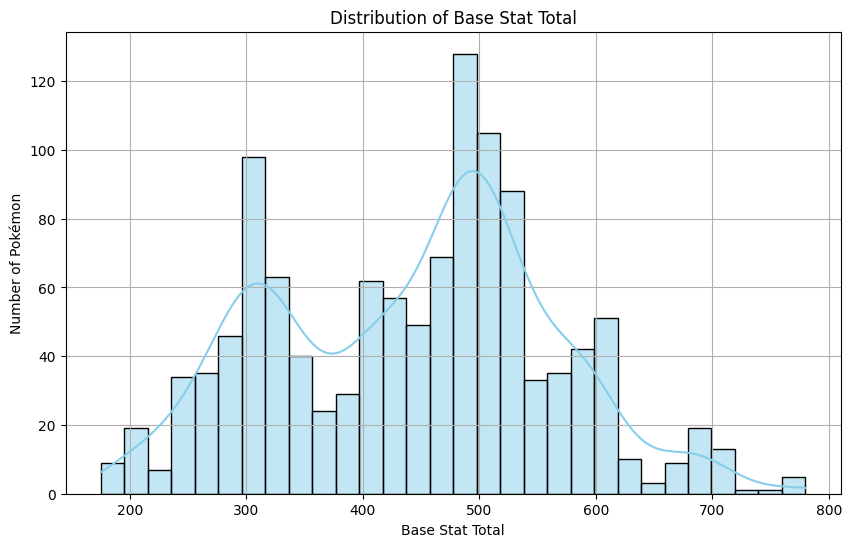

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Base Stat Total'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Base Stat Total')
plt.xlabel('Base Stat Total')
plt.ylabel('Number of Pokémon')
plt.grid(True)
plt.show()


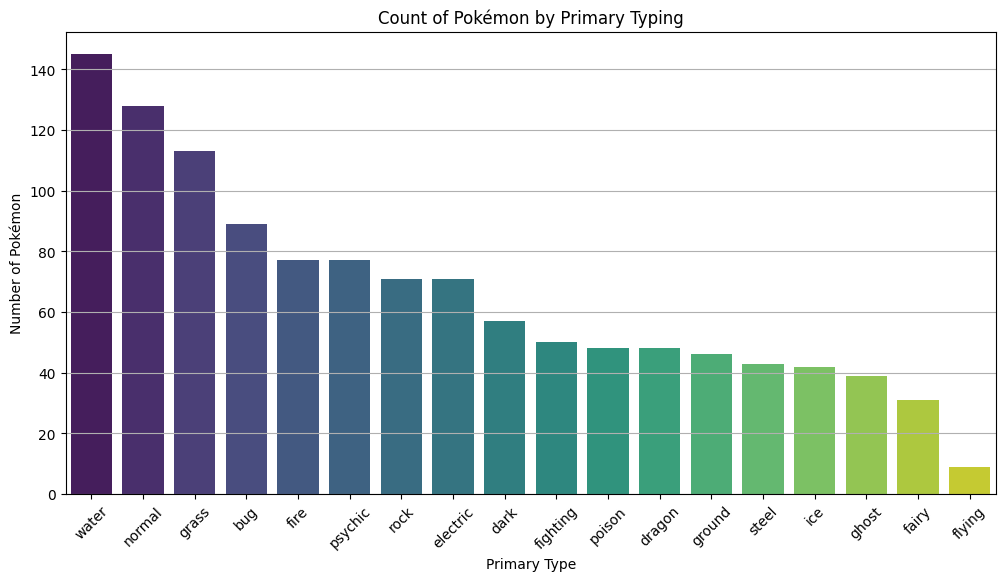

In [13]:
plt.figure(figsize=(12, 6))
type_counts = df['Primary Typing'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')
plt.title('Count of Pokémon by Primary Typing')
plt.xlabel('Primary Type')
plt.ylabel('Number of Pokémon')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


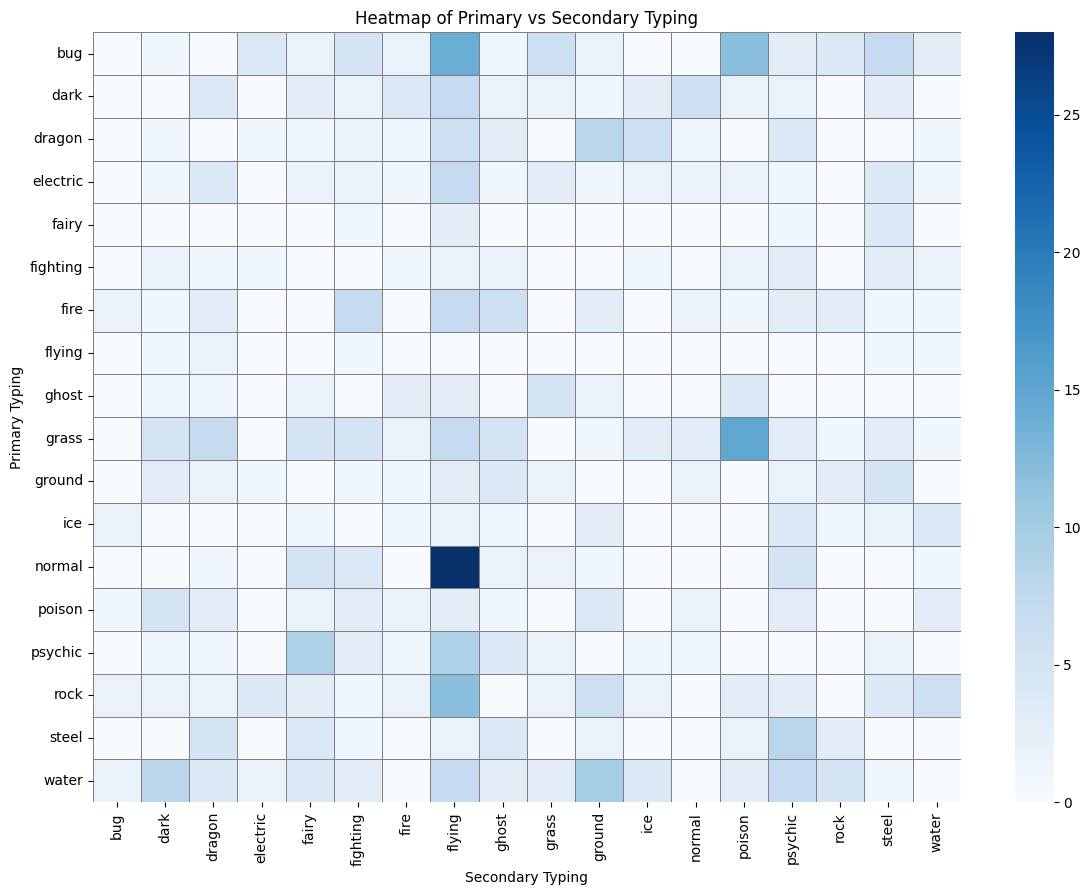

In [14]:
type_combo = pd.crosstab(df['Primary Typing'], df['Secondary Typing'])
plt.figure(figsize=(14, 10))
sns.heatmap(type_combo, cmap='Blues', linewidths=0.5, linecolor='gray')
plt.title('Heatmap of Primary vs Secondary Typing')
plt.xlabel('Secondary Typing')
plt.ylabel('Primary Typing')
plt.show()


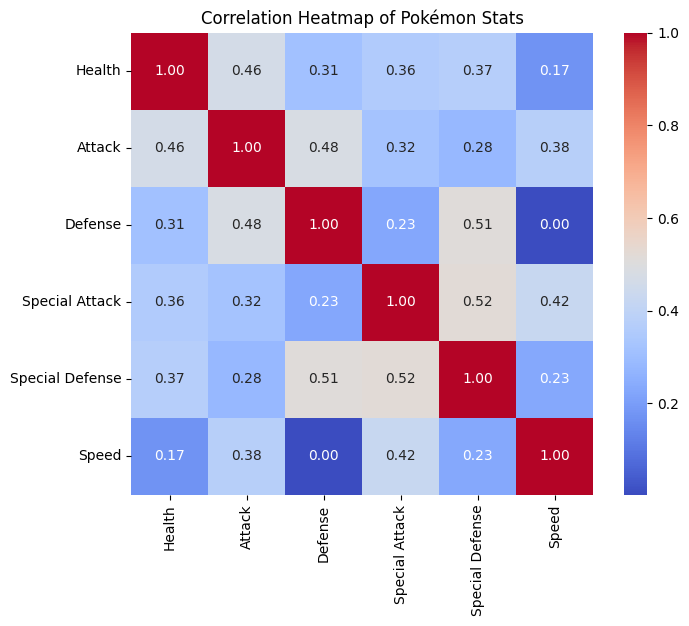

In [15]:
stat_cols = ['Health', 'Attack', 'Defense', 'Special Attack', 'Special Defense', 'Speed']
corr = df[stat_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Pokémon Stats')
plt.show()


## predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [17]:
# Optional: XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

In [18]:
# Fill missing values if any
df.fillna("None", inplace=True)

In [19]:
# Select Features and Target
features = ['Primary Typing', 'Secondary Typing', 'Generation', 'Health', 'Attack',
            'Defense', 'Special Attack', 'Special Defense', 'Speed',
            'Catch Rate', 'Height (in)', 'Weight (lbs)']
target = 'Legendary Status'


In [20]:
X = df[features].copy()
y = df[target].copy()

In [21]:
# Label encode all object columns in X
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

In [22]:
# Encode target if it's not numeric
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)


In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [25]:
# Train, predict, evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    results.append((name, acc))

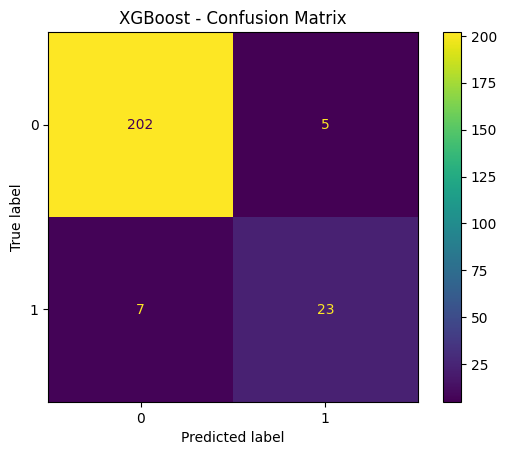

In [26]:
# Plot confusion matrix
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"{name} - Confusion Matrix")
plt.show()


In [27]:
# Display accuracy results
print("\n🔍 Model Accuracies:\n")
for name, acc in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"{name}: {acc:.2f}%")


🔍 Model Accuracies:

Logistic Regression: 97.05%
XGBoost: 94.94%
Random Forest: 94.09%
SVM: 94.09%
Decision Tree: 92.41%
Naive Bayes: 91.14%
KNN: 91.14%


## THank you...pls upvote!!!